In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../output/combined_projections.csv")

In [3]:
df_long = df.melt(
    id_vars=["model_name", "model_variation", "dimension"], 
    value_vars=["female_names", "male_names"], 
    var_name="gender", 
    value_name="score"
)
df_long["gender"] = df_long["gender"].str.replace("_names", "").str.capitalize()

def get_group(val):
    if "default" in val:
        return "Default"
    for v in ["conservative", "democratic", "liberal"]:
        if v in val:
            return v.capitalize()
    return "Other"

df_long["variation_group"] = df_long["model_variation"].apply(get_group)

In [ ]:
from scipy.stats import wilcoxon, ttest_1samp

default_map = df_long[df_long["variation_group"] == "Default"].set_index(
    ["model_name", "dimension", "gender"]
)["score"]

def perform_ttest(group):
    model, var_group, dim, gender = group.name
    baseline = default_map.loc[(model, dim, gender)]
    
    # T-Test
    t_stat, p_val = ttest_1samp(group["score"], popmean=baseline)
    return p_val

variations_only = df_long[df_long["variation_group"] != "Default"]

p_values_series = variations_only.groupby(
    ["model_name", "variation_group", "dimension", "gender"]
).apply(perform_ttest, include_groups=False)

significance_df = p_values_series.reset_index(name="p_value")

Plotting: Apertus-8B-Instruct-2509: Default vs Conservative...
Plotting: Meta-Llama-3-8B: Default vs Conservative...
Plotting: Qwen3-8B: Default vs Conservative...
Plotting: Apertus-8B-Instruct-2509: Default vs Democratic...
Plotting: Meta-Llama-3-8B: Default vs Democratic...
Plotting: Qwen3-8B: Default vs Democratic...
Plotting: Apertus-8B-Instruct-2509: Default vs Liberal...
Plotting: Meta-Llama-3-8B: Default vs Liberal...
Plotting: Qwen3-8B: Default vs Liberal...


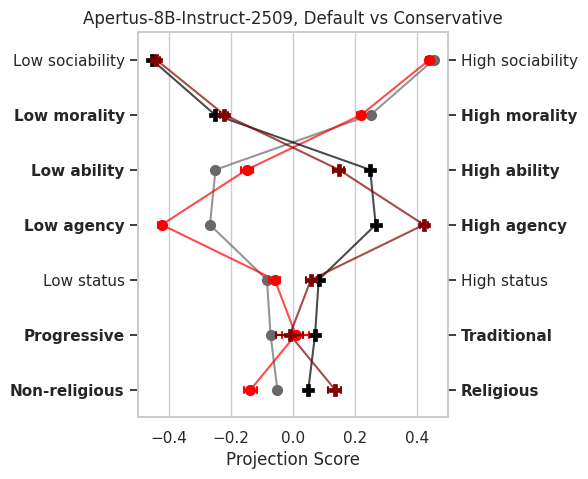

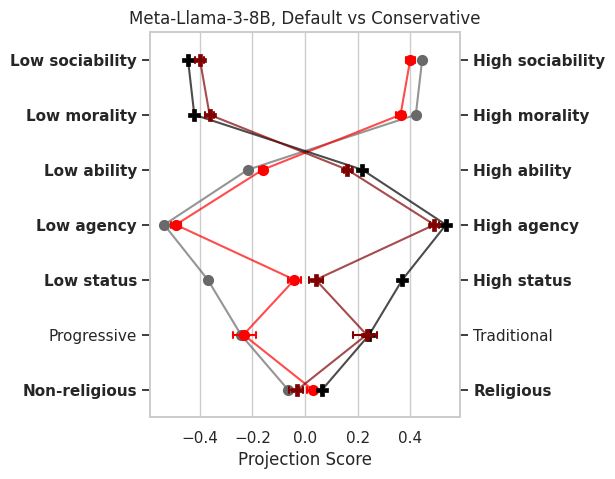

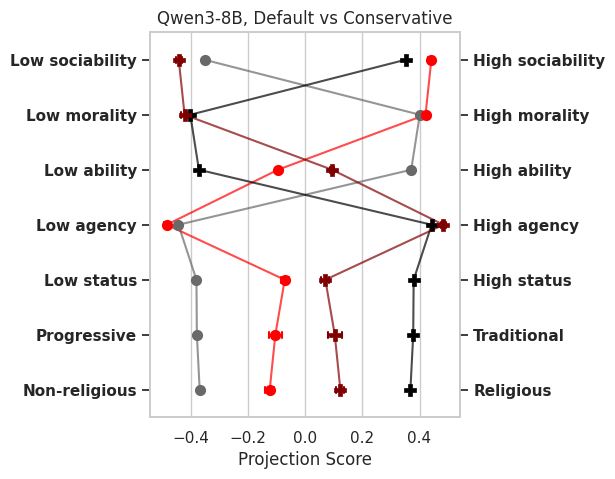

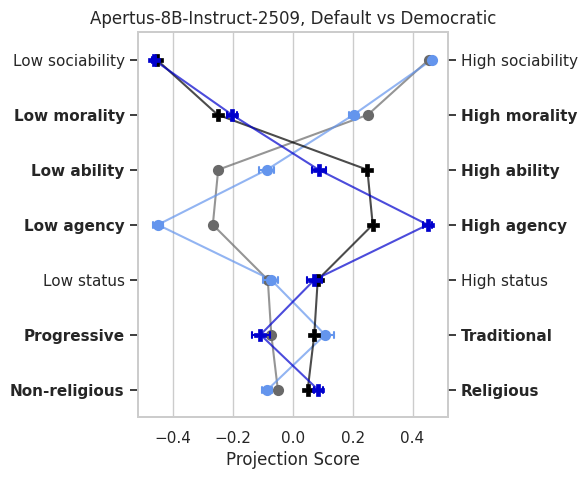

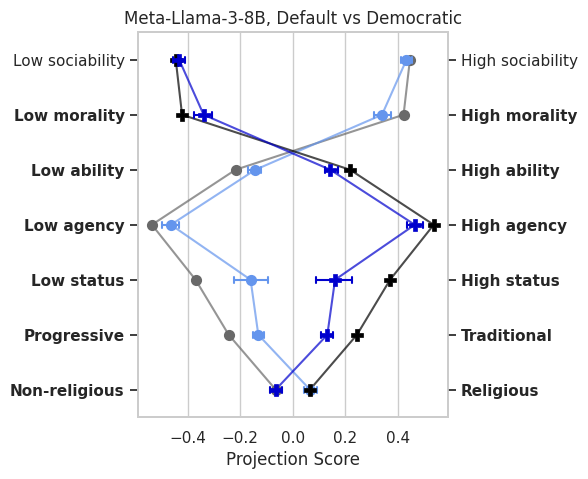

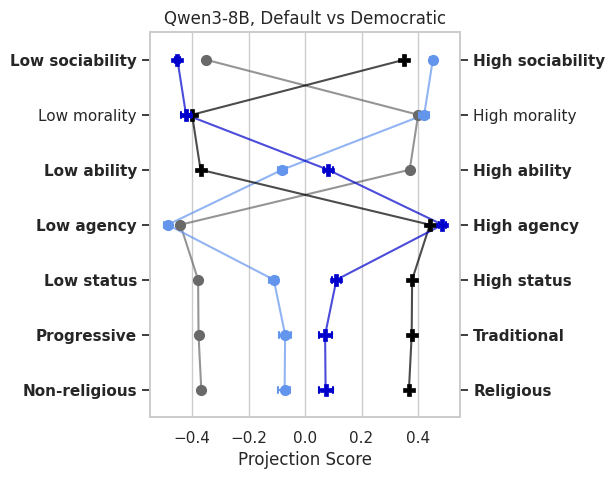

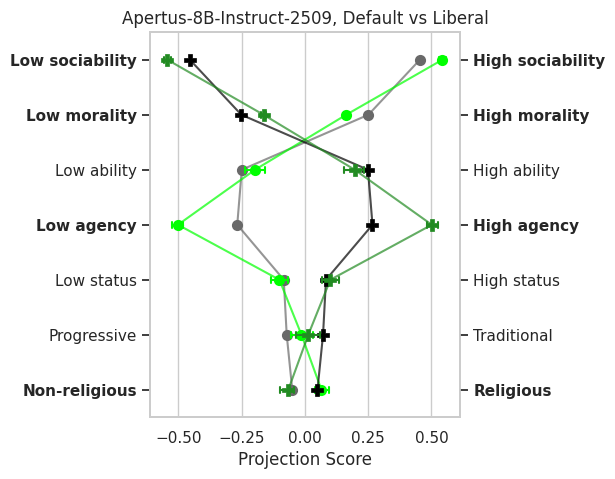

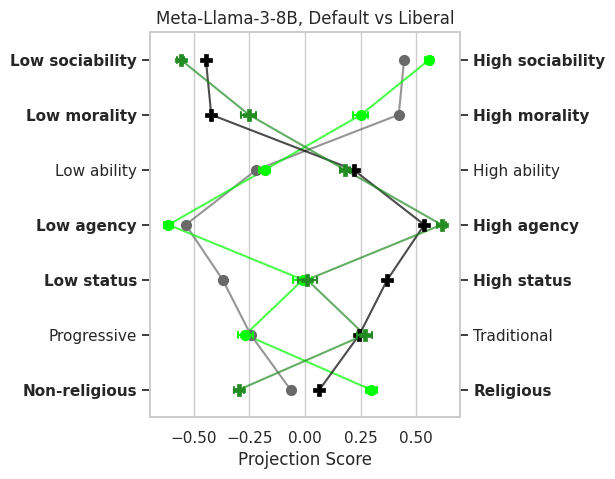

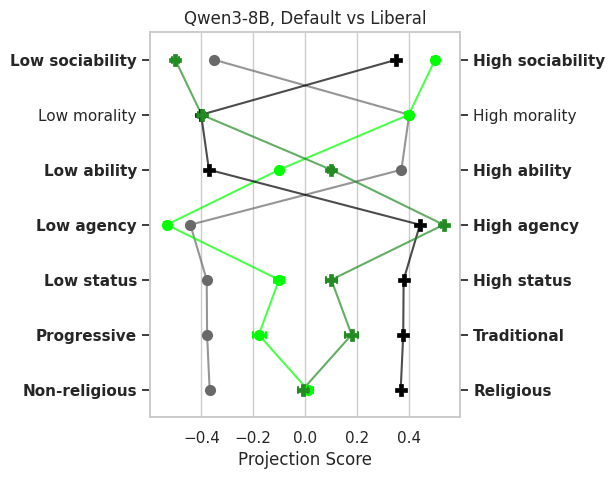

In [ ]:
alpha = 0.01

target_aspects = ["Conservative", "Democratic", "Liberal"]

female_palette = {
    "Default": "dimgrey",
    "Conservative": "red", 
    "Liberal": "lime",      
    "Democratic": "cornflowerblue"    
}

male_palette = {
    "Default": "black",
    "Conservative": "maroon", 
    "Liberal": "forestgreen",      
    "Democratic": "mediumblue"    
}

low_labels = {
    "Sociability": "Low sociability",
    "Morality": "Low morality",
    "Ability": "Low ability",
    "Agency": "Low agency",
    "Status": "Low status",
    "Politics": "Progressive",
    "Religion": "Non-religious"
}

high_labels = {
    "Sociability": "High sociability",
    "Morality": "High morality",
    "Ability": "High ability",
    "Agency": "High agency",
    "Status": "High status",
    "Politics": "Traditional",
    "Religion": "Religious"
}

for aspect in target_aspects:
    for model in df_long["model_name"].unique():
        print(f"Plotting: {model}: Default vs {aspect}...")
        
        subset_df = df_long[
            (df_long["variation_group"].isin(["Default", aspect])) & 
            (df_long["model_name"] == model)
        ].copy()
        
        sns.set_theme(style="whitegrid")
        fig, ax = plt.subplots(figsize=(4, 5))
    
        ax.set_title(f"{model}, Default vs {aspect}")
    
        ax = plt.gca()
        current_hue_order = ["Default", aspect]
        
        # Female Lines
        sns.pointplot(
            data=subset_df[subset_df["gender"] == "Female"],
            x="score", y="dimension", hue="variation_group",
            hue_order=current_hue_order, palette=female_palette,
            markers=".",        
            markersize=0,      
            markeredgewidth=0,  
            linestyles="-",     
            dodge=0,              
            errorbar=None,      
            linewidth=1.5,      
            alpha=0.7,          
            ax=ax
        )
        
        # Male Lines
        sns.pointplot(
            data=subset_df[subset_df["gender"] == "Male"],
            x="score", y="dimension", hue="variation_group",
            hue_order=current_hue_order, palette=male_palette,
            markers=".",        
            markersize=0,       
            markeredgewidth=0,  
            linestyles="-",    
            dodge=0,              
            errorbar=None, 
            linewidth=1.5,
            alpha=0.7, 
            ax=ax
        )
        
        # Female Markers
        sns.pointplot(
            data=subset_df[subset_df["gender"] == "Female"],
            x="score", y="dimension", hue="variation_group",
            hue_order=current_hue_order, palette=female_palette,
            markers="o",        
            markersize=6,       
            linestyles="",     
            dodge=0,              
            errorbar=("ci", 95),
            err_kws={'linewidth': 1.5},
            capsize=0.1,
            alpha=1.0,          
            ax=ax
        )

        # Male Markers
        sns.pointplot(
            data=subset_df[subset_df["gender"] == "Male"],
            x="score", y="dimension", hue="variation_group",
            hue_order=current_hue_order, palette=male_palette,
            markers="P",        
            markersize=8,       
            markeredgewidth=0.5,
            linestyles="",      
            dodge=0,              
            errorbar=("ci", 95),
            err_kws={'linewidth': 1.5},
            capsize=0.1,
            alpha=1.0,          
            ax=ax
        )
        
        if ax.get_legend():
            ax.get_legend().remove()
        
        ax.set_xlabel("Projection Score")
        ax.set_ylabel("")
        
        fig.canvas.draw()
        
        bold_rows = []
        
        for dim in low_labels.keys():
            l_text = low_labels.get(dim, dim)
            r_text = high_labels.get(dim, dim)
            p_female_row = significance_df[
                (significance_df["model_name"] == model) & 
                (significance_df["dimension"] == dim) & 
                (significance_df["gender"] == "Female") &
                (significance_df["variation_group"] == aspect)
            ]
            p_f = p_female_row["p_value"].values[0]
            p_male_row = significance_df[
                (significance_df["model_name"] == model) & 
                (significance_df["dimension"] == dim) & 
                (significance_df["gender"] == "Male") &
                (significance_df["variation_group"] == aspect)
            ]
            p_m = p_male_row["p_value"].values[0]

            bold_rows.append(p_f < alpha and p_m < alpha)

        ax.set_yticks(ax.get_yticks())
        ax.set_yticklabels(low_labels.values())
        
        ax.tick_params(labelright=True, right=True)
        ax2 = ax.twinx()
        ax2.set_ylim(ax.get_ylim()) 
        ax2.set_yticks(ax.get_yticks())      
        ax2.set_yticklabels(high_labels.values())

        for i, (label1, label2) in enumerate(zip(ax.get_yticklabels(), ax2.get_yticklabels())):
            if bold_rows[i]:
                label1.set_fontweight('bold')
                label2.set_fontweight('bold')
        
        ax2.grid(False)
    
        plt.savefig(f"../figures/{model}_{aspect}.pdf", bbox_inches='tight')